# Brazilian Space Objects – Exploratory Data Analysis

This notebook explores a dataset of Brazilian space objects (satellites), including launch data, orbit types, mission purposes, and involved entities.

![Cover](https://upload.wikimedia.org/wikipedia/commons/thumb/5/59/AEB-Brazil.svg/1280px-AEB-Brazil.svg.png)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("/kaggle/input/datasets/romeiro/brazilian-space-objects-analytics-dataset/brazilian_space_objects_analytics.csv")

## Launch Trends Over Time

Satellite launches related to Brazil show a historically irregular pattern, with significant growth and peak activity occurring after 2014, particularly between **2019** and **2022**, indicating a **recent expansion phase in the country’s space activities**.

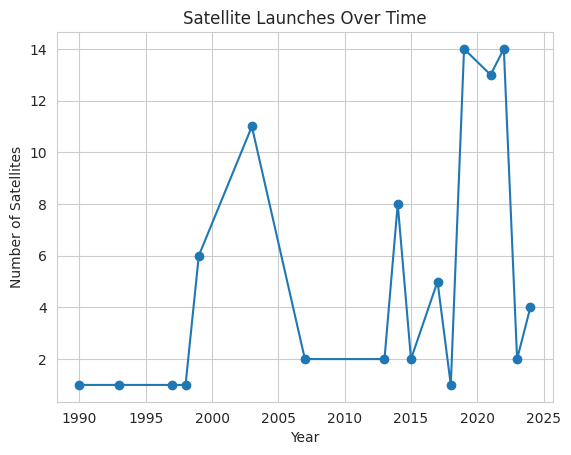

In [2]:
df["data_lancamento"] = pd.to_datetime(df["data_lancamento"], errors="coerce")
df["ano_lancamento"] = df["data_lancamento"].dt.year

launches_per_year = df["ano_lancamento"].value_counts().sort_index()

plt.figure()
launches_per_year.plot(kind="line", marker="o")
plt.title("Satellite Launches Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Satellites")
plt.show()

## Orbit Distribution

The dataset reveals a **strong concentration of satellites in Low Earth Orbit (LEO)**, with limited use of geostationary orbit and a **notable portion of missing orbit data**, highlighting both operational focus and data completeness challenges.

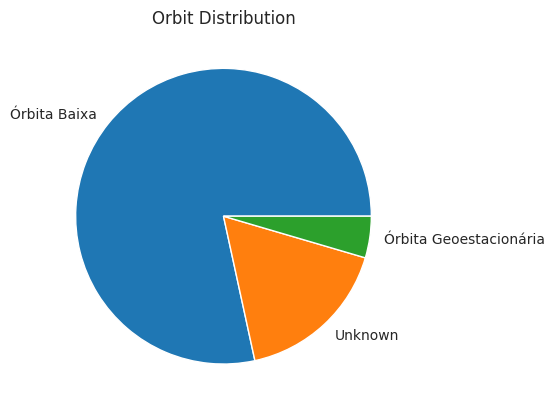

In [3]:
orbit_counts = df["orbita_descricao"].fillna("Unknown").value_counts()

plt.figure()
orbit_counts.plot(kind="pie")
plt.title("Orbit Distribution")
plt.xlabel("")
plt.ylabel("")
plt.show()

## Mission Categories

Satellite missions are primarily focused on **technology development**, **Earth observation**, and **educational purposes**, indicating a strong emphasis on capability building, applied use cases, and human capital development, with limited participation in telecommunications and scientific missions.

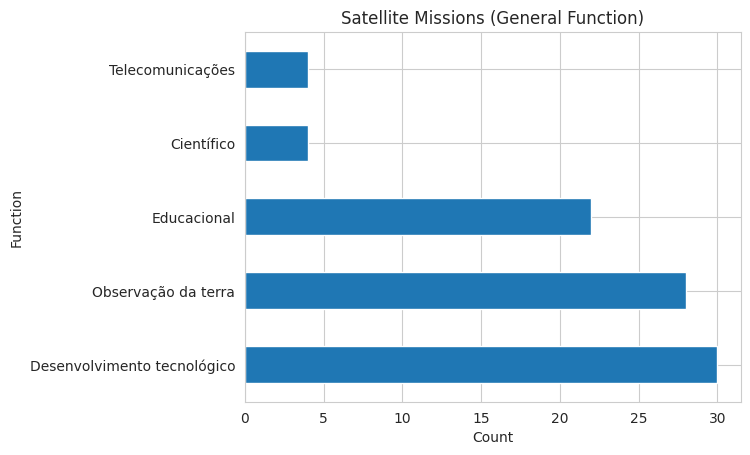

In [4]:
func_counts = df["funcao_geral_descricao"].value_counts()

plt.figure()
func_counts.plot(kind="barh")
plt.title("Satellite Missions (General Function)")
plt.xlabel("Count")
plt.ylabel("Function")
plt.show()

## Top Launch Vehicles

Satellite launches are **heavily concentrated among a few international vehicles** — particularly **Long March** and **Falcon 9** — indicating strong reliance on foreign launch providers, while domestic capabilities such as VLS play a limited role.

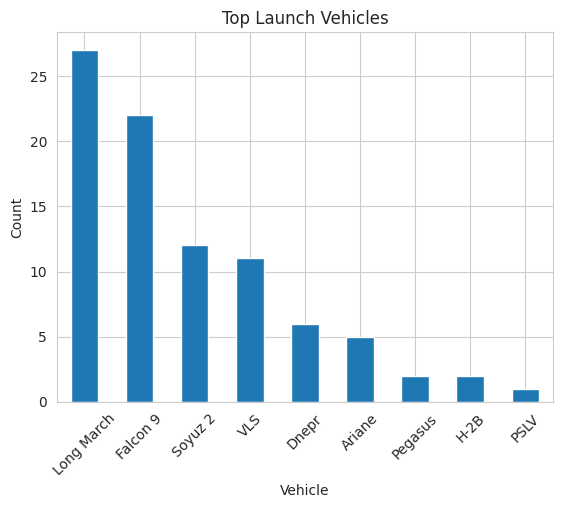

In [5]:
vehicle_counts = df["veiculo_nome"].value_counts().head(10)

plt.figure()
vehicle_counts.plot(kind="bar")
plt.title("Top Launch Vehicles")
plt.xlabel("Vehicle")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Top Entities (Owners)

Satellite ownership is highly concentrated, with **INPE** leading by a large margin, followed by government and academic institutions, indicating a **predominantly public and research-driven space ecosystem** with limited but emerging private sector participation.

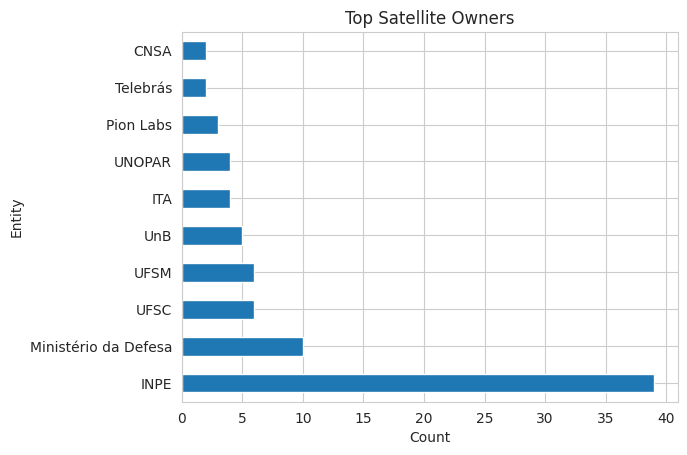

In [6]:
owner_counts = df["proprietario_nome"].value_counts().head(10)

plt.figure()
owner_counts.plot(kind="barh")
plt.title("Top Satellite Owners")
plt.xlabel("Count")
plt.ylabel("Entity")
plt.show()

## Satellite Status

More than half of the satellites remain operational, while a significant portion has reached end-of-life and around **20% experienced failures** — primarily during launch — highlighting both **operational maturity** and the **inherent risks of space missions**.

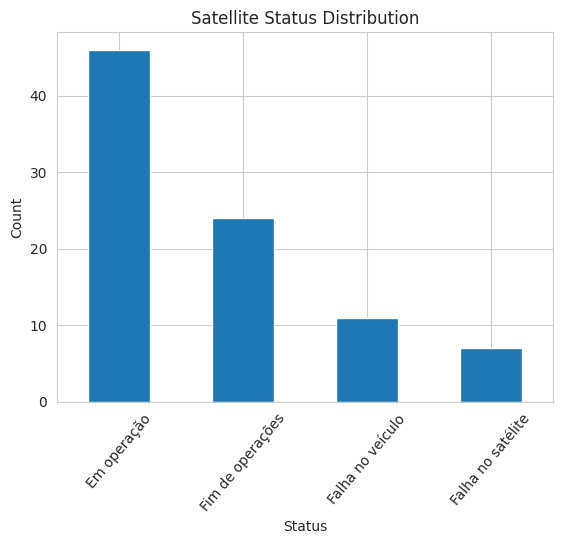

In [7]:
df["status_descricao"] = df["status_descricao"].replace("Falha por destruição do veículo lançador", "Falha no veículo")
status_counts = df["status_descricao"].value_counts()

plt.figure()
status_counts.plot(kind="bar")
plt.title("Satellite Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.xticks(rotation=50)
plt.show()

## Conclusion

This dataset provides a comprehensive view of Brazilian space activities, revealing a program that has evolved from sporadic early launches into a more active and structured ecosystem in recent years. The analysis shows that satellite launches have increased significantly after 2014, reaching peak activity between 2019 and 2022, although with noticeable variability over time.

From an operational perspective, most satellites are concentrated in Low Earth Orbit (LEO), reinforcing a focus on cost-effective and practical missions such as Earth observation and technology development. Mission distribution further highlights strong investment in technological innovation, applied use cases, and educational initiatives, while areas such as telecommunications and advanced scientific missions remain less explored.

The ecosystem is predominantly driven by public institutions, with INPE and government entities playing a central role, complemented by strong participation from universities. Private sector involvement exists but is still emerging. Additionally, the heavy reliance on international launch vehicles indicates a high level of global integration, but also limited domestic launch autonomy.

Finally, while more than half of the satellites remain operational, the dataset also reflects the inherent risks of space missions, with a notable share of failures—particularly during the launch phase—and a natural lifecycle progression of satellite decommissioning.

Overall, this dataset illustrates a space program focused on capability building, research, and practical applications, with clear opportunities for growth in commercialization, international competitiveness, and diversification of mission profiles.
